# VEGFR2 (CHEMBL279) — Results

Three figures that together tell the project's story:

1. **Parity plots** — predicted vs. true pIC50, random split vs. scaffold split, side by side. The gap between these two is the cost of evaluating honestly.
2. **Error vs. nearest-training-neighbor Tanimoto** — for the scaffold-split test set, how prediction error scales with chemical novelty.
3. **pIC50 distribution per split** — a sanity check that the splits aren't accidentally biased.

In [1]:
import sys
from pathlib import Path

# Make `src` importable when this notebook is executed from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, r2_score

from src.config import PROCESSED_DIR, TARGET_CHEMBL_ID
from src.evaluation import _tanimoto_nn

TARGET = TARGET_CHEMBL_ID
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

preds = pd.read_csv(PROCESSED_DIR / f'{TARGET}_predictions.csv')
fps_npz = np.load(PROCESSED_DIR / f'{TARGET}_morgan2_2048.npz', allow_pickle=False)
fp_smiles = pd.Series(np.arange(len(fps_npz['canonical_smiles'])),
                      index=fps_npz['canonical_smiles'])
fps = fps_npz['fingerprints']
print(f'{len(preds):,} prediction rows; {len(fps):,} fingerprints loaded.')

36,220 prediction rows; 9,055 fingerprints loaded.


## 1. Parity: random split vs scaffold split (GBM, test set)

Each point is one held-out compound. The 45° line is perfect prediction. The honest evaluation lives on the right.

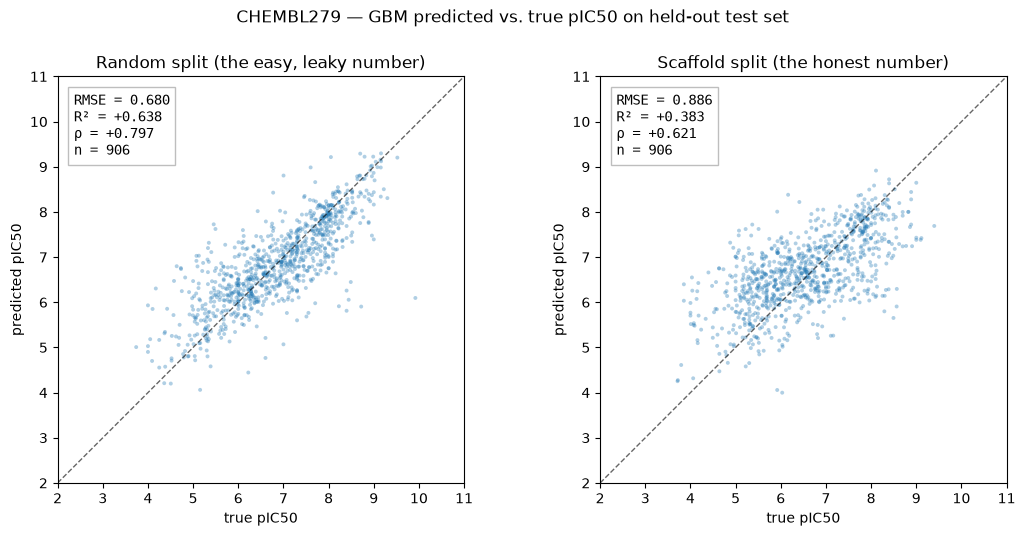

In [2]:
def parity(ax, sub, title):
    y_true, y_pred = sub['y_true'].values, sub['y_pred'].values
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    rho = float(spearmanr(y_true, y_pred)[0])
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, edgecolors='none')
    lo, hi = 2.0, 11.0
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.6)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('true pIC50'); ax.set_ylabel('predicted pIC50')
    ax.set_title(title)
    ax.text(0.04, 0.96,
            f'RMSE = {rmse:.3f}\nR² = {r2:+.3f}\n\u03c1 = {rho:+.3f}\nn = {len(sub):,}',
            transform=ax.transAxes, va='top', ha='left',
            fontsize=10, family='monospace',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='0.7'))
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
test_random = preds.query("split == 'test' and split_type == 'random' and model == 'gbm'")
test_scaffold = preds.query("split == 'test' and split_type == 'scaffold' and model == 'gbm'")
parity(axes[0], test_random, 'Random split (the easy, leaky number)')
parity(axes[1], test_scaffold, 'Scaffold split (the honest number)')
fig.suptitle(f'{TARGET} \u2014 GBM predicted vs. true pIC50 on held-out test set', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'parity_random_vs_scaffold.png', dpi=130, bbox_inches='tight')
plt.show()

## 2. Error vs. nearest-training-neighbor Tanimoto similarity

For each scaffold-split test compound, the x-axis is the maximum Tanimoto similarity (over Morgan ECFP4 fingerprints) to *any* training compound. The y-axis is the absolute prediction error. The red line is a binned mean, showing the monotonic relationship between chemical novelty and error.

This is the model's **domain of applicability** — where its predictions can be trusted, and where they cannot.

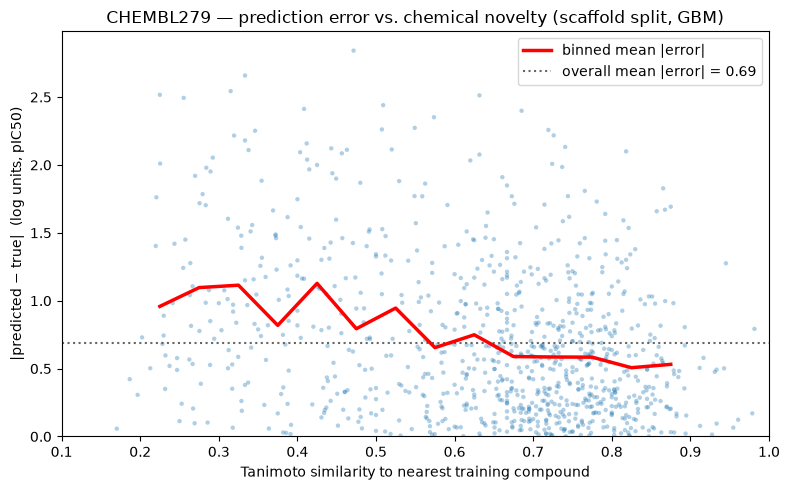


Test-set NN Tanimoto: min=0.17, median=0.68, max=0.98


In [3]:
sub = preds.query("split_type == 'scaffold' and model == 'gbm'")
train_smi = sub.loc[sub['split'] == 'train', 'canonical_smiles']
test_rows = sub[sub['split'] == 'test'].reset_index(drop=True).copy()

train_fp = fps[fp_smiles.reindex(train_smi).to_numpy()]
test_fp = fps[fp_smiles.reindex(test_rows['canonical_smiles']).to_numpy()]
test_rows['nn_tanimoto'] = _tanimoto_nn(test_fp, train_fp)
test_rows['abs_err'] = (test_rows['y_true'] - test_rows['y_pred']).abs()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(test_rows['nn_tanimoto'], test_rows['abs_err'],
           s=10, alpha=0.35, edgecolors='none')

# Binned mean trend (red), 0.05-wide bins
bins = np.arange(0.10, 1.01, 0.05)
centers, means = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    b = test_rows[(test_rows['nn_tanimoto'] >= lo) & (test_rows['nn_tanimoto'] < hi)]
    if len(b) >= 10:
        centers.append((lo + hi) / 2)
        means.append(b['abs_err'].mean())
ax.plot(centers, means, 'r-', lw=2.5, label='binned mean |error|', zorder=5)

ax.axhline(test_rows['abs_err'].mean(), color='0.4', ls=':',
           label=f"overall mean |error| = {test_rows['abs_err'].mean():.2f}")
ax.set_xlabel('Tanimoto similarity to nearest training compound')
ax.set_ylabel('|predicted \u2212 true|  (log units, pIC50)')
ax.set_title(f'{TARGET} \u2014 prediction error vs. chemical novelty (scaffold split, GBM)')
ax.legend(loc='upper right')
ax.set_xlim(0.1, 1.0)
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(FIG_DIR / 'error_vs_tanimoto_nn.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"\nTest-set NN Tanimoto: min={test_rows['nn_tanimoto'].min():.2f}, "
      f"median={test_rows['nn_tanimoto'].median():.2f}, max={test_rows['nn_tanimoto'].max():.2f}")

## 3. pIC50 distributions per split (sanity check)

Are the scaffold-split test compounds drawn from a different pIC50 distribution than train? A small downward shift is expected (rarer scaffolds tend to be from exploratory papers and slightly less potent on average) — we want this visible and small, not large.

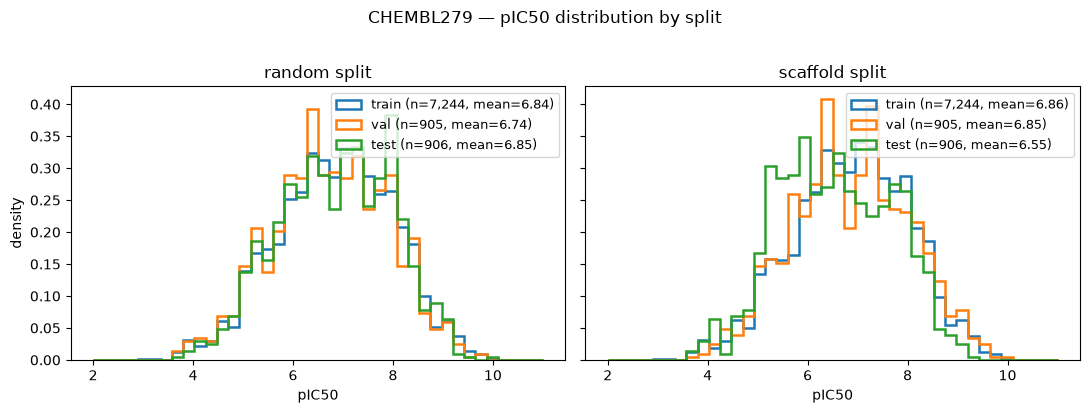

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, kind in zip(axes, ('random', 'scaffold')):
    sub = preds.query("split_type == @kind and model == 'gbm'")
    by_split = sub.drop_duplicates('canonical_smiles')
    for split, color in (('train', 'C0'), ('val', 'C1'), ('test', 'C2')):
        vals = by_split.loc[by_split['split'] == split, 'y_true']
        ax.hist(vals, bins=40, range=(2, 11), histtype='step', lw=1.8,
                density=True, color=color, label=f'{split} (n={len(vals):,}, mean={vals.mean():.2f})')
    ax.set_xlabel('pIC50'); ax.set_title(f'{kind} split')
    ax.legend(loc='upper right', fontsize=9)
axes[0].set_ylabel('density')
fig.suptitle(f'{TARGET} \u2014 pIC50 distribution by split', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'pic50_by_split.png', dpi=130, bbox_inches='tight')
plt.show()